In [2]:
import pandas as pd
import xarray as xr

In [16]:
gfw_data = xr.open_zarr('./data/processed/GFW_AIS.zarr')
intl_fishing_area = xr.open_dataarray('./data/processed/static/area_pesca_0.125.nc')

In [21]:
ds = gfw_data
ds = ds.where(intl_fishing_area)
# 1. mask TRAWLERS
ds_trawlers = ds.where(ds.geartype == "TRAWLERS", drop=True)
grouped = ds_trawlers["hours"].groupby(ds_trawlers.flag.astype(str))

# 3. sum over space and keep time + flag groups
result = grouped.sum(dim=["lat", "lon"])

# 4. convert to dataframe
df = result.to_dataframe(name="hours").reset_index()
df = df[["time", "flag", "hours"]]
df["time"] = pd.to_datetime(df["time"])

year_from = "2020"
df1 = df[df["time"] >= f"{year_from}-01-01"]
df1

,time,flag,hours
2592,2020-01-01,ALB,0.000000
2593,2020-01-01,ARE,0.000000
2594,2020-01-01,ARG,0.000000
2595,2020-01-01,BLZ,0.000000
2596,2020-01-01,CHL,0.000000
...,...,...,...
4207,2024-12-01,TUV,0.000000
4208,2024-12-01,TWN,0.000000
4209,2024-12-01,UKR,0.000000
4210,2024-12-01,URY,0.000000


<Axes: title={'center': 'Total hours by flag for TRAWLERS from 2020'}, xlabel='flag'>

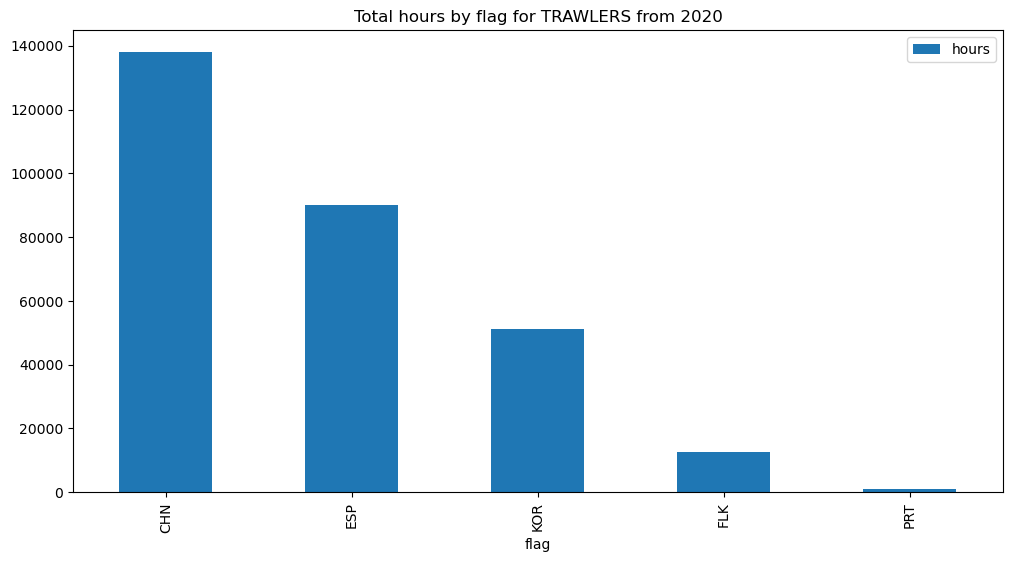

In [24]:

df_flag = (
    df1.groupby("flag", as_index=False)["hours"]
      .sum()
      .sort_values("hours", ascending=False)
)
df_top = df_flag.head(5)

df_top.plot.bar(x="flag", y="hours", title=f"Total hours by flag for TRAWLERS from {year_from}", figsize=(12, 6))